# INTRODUCCIÓN

Este proyecto consiste en analizar los datos de una empresa emergente del sector alimenticio que busca comprender mejor el comportamiento de los usuarios en su aplicación.  

La primera parte del análisis se centra en el **embudo de ventas**, con el objetivo de identificar cuántos usuarios logran llegar hasta la etapa de compra, cuántos se quedan en fases previas y en qué puntos específicos se presentan más fricciones.  

Posteriormente, se estudian los resultados de un **experimento A/A/B**. El equipo de diseño está interesado en cambiar las fuentes de la aplicación, mientras que la gerencia duda sobre el impacto que esto pueda tener en la experiencia de los usuarios. Para tomar una decisión fundamentada, se realiza una prueba en la que los usuarios se dividen en tres grupos: dos grupos de control que mantienen las fuentes originales y un grupo de prueba que recibe el nuevo diseño.  

El uso de **dos grupos A** ofrece ventajas: permite comprobar la confiabilidad de los resultados al comparar los controles entre sí y detectar posibles factores externos que influyan en el experimento. Además, esta comparación ayuda a estimar con mayor precisión el tiempo y la cantidad de datos necesarios para futuros estudios.  

En este proyecto se emplea un mismo conjunto de datos tanto para el análisis general como para la evaluación del test A/A/B, tal como ocurre en entornos reales, donde los equipos de análisis utilizan la información disponible sin distinguir entre usuarios que participan o no en experimentos.  



In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## 1. Exploración de los datos

In [2]:
# Convertir el artchivo csv en un dataframe
registros_df = pd.read_csv("/datasets/logs_exp_us.csv", sep = '\t')

In [3]:
# Imprimir el dataframe
registros_df

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248
...,...,...,...,...
244121,MainScreenAppear,4599628364049201812,1565212345,247
244122,MainScreenAppear,5849806612437486590,1565212439,246
244123,MainScreenAppear,5746969938801999050,1565212483,246
244124,MainScreenAppear,5746969938801999050,1565212498,246


In [4]:
# Información general
registros_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


### Discripción de los datos

Cada entrada de registro es una acción de usuario o un evento.

- EventName: nombre del evento.
- DeviceIDHash: identificador de usuario unívoco.
- EventTimestamp: hora del evento.
- ExpId: número de experimento. 246 y 247 son los grupos de control, y 248 es el grupo de prueba.

## 2 Preparación de los datos

In [5]:
# Convertir EventTimestamp a datetime
registros_df['EventTimestamp'] = pd.to_datetime(registros_df['EventTimestamp'], unit='s')

In [6]:
# Renombrar las demás colunas
registros_df = registros_df.rename(columns={
    'EventName': 'Event',
    'DeviceIDHash': 'SourceID',
    'ExpId': 'Group'
})

In [7]:
registros_df

,Event,SourceID,EventTimestamp,Group
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36,246
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42,246
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47,248
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47,248
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42,248
...,...,...,...,...
244121,MainScreenAppear,4599628364049201812,2019-08-07 21:12:25,247
244122,MainScreenAppear,5849806612437486590,2019-08-07 21:13:59,246
244123,MainScreenAppear,5746969938801999050,2019-08-07 21:14:43,246
244124,MainScreenAppear,5746969938801999050,2019-08-07 21:14:58,246


In [8]:
# Transformar la columna Group a tipo object y renombrar los valores
registros_df['Group'] = registros_df['Group'].astype('object').replace({
    246: 'A1',
    247: 'A2',
    248: 'B'
})

In [9]:
# Crear la columna 'Date' extrayendo solo la fecha de 'EventTimestamp'
registros_df['Date'] = registros_df['EventTimestamp'].dt.date

# Reorganizar las columnas para colocar 'Date' entre 'EventTimestamp' y 'Group'
registros_df = registros_df[['Event', 'SourceID', 'EventTimestamp', 'Date', 'Group']]

In [10]:
# Revisar los cambios en el dataframe
registros_df

,Event,SourceID,EventTimestamp,Date,Group
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36,2019-07-25,A1
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42,2019-07-25,A1
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47,2019-07-25,B
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47,2019-07-25,B
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42,2019-07-25,B
...,...,...,...,...,...
244121,MainScreenAppear,4599628364049201812,2019-08-07 21:12:25,2019-08-07,A2
244122,MainScreenAppear,5849806612437486590,2019-08-07 21:13:59,2019-08-07,A1
244123,MainScreenAppear,5746969938801999050,2019-08-07 21:14:43,2019-08-07,A1
244124,MainScreenAppear,5746969938801999050,2019-08-07 21:14:58,2019-08-07,A1


In [11]:
registros_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Event           244126 non-null  object        
 1   SourceID        244126 non-null  int64         
 2   EventTimestamp  244126 non-null  datetime64[ns]
 3   Date            244126 non-null  object        
 4   Group           244126 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 9.3+ MB


In [12]:
# Comprobar valores nulos en cada columna
null_values = registros_df.isnull().sum()
print(null_values)

Event             0
SourceID          0
EventTimestamp    0
Date              0
Group             0
dtype: int64


In [13]:
# Verificar si algún usuario aparece en más de un grupo
# Agrupar por SourceID y contar los grupos distintos
sourceid_grupos = registros_df.groupby('SourceID')['Group'].nunique()

# Filtrar los SourceID que aparecen en más de un grupo
sourceid_multiples_grupos = sourceid_grupos[sourceid_grupos > 1]

# Mostrar resultados
if sourceid_multiples_grupos.empty:
    print("No hay usuarios que aparezcan en más de un grupo.")
else:
    print("Usuarios que aparecen en más de un grupo:")
    print(sourceid_multiples_grupos)

No hay usuarios que aparezcan en más de un grupo.


## 3 Estudiar y comprobar los datos

### 3.1 ¿Cuántos eventos hay en los registros?

In [14]:
# Contar el total de eventos (filas en el dataset)
total_eventos = registros_df.shape[0]
print(f"Total de eventos: {total_eventos}")

Total de eventos: 244126


### 3.2 ¿Cuántos usuarios hay en los registros?

In [15]:
usuarios_unicos = registros_df["SourceID"].nunique()
print(f"Total de usuarios únicos: {usuarios_unicos}")

Total de usuarios únicos: 7551


### 3.3 ¿Cuál es el promedio de eventos por usuario?

In [16]:
promedio_eventos_usuario = round(total_eventos / usuarios_unicos, 2)
print(f"Promedio de eventos por usuario: {promedio_eventos_usuario}")

Promedio de eventos por usuario: 32.33


### 3.4 ¿Qué periodo de tiempo cubren los datos?

In [17]:
# Encontrar la fecha mínima y máxima
fecha_minima = registros_df['Date'].min()
fecha_maxima = registros_df['Date'].max()
print(f"Fecha mínima: {fecha_minima}")
print(f"Fecha máxima: {fecha_maxima}")

Fecha mínima: 2019-07-25
Fecha máxima: 2019-08-07


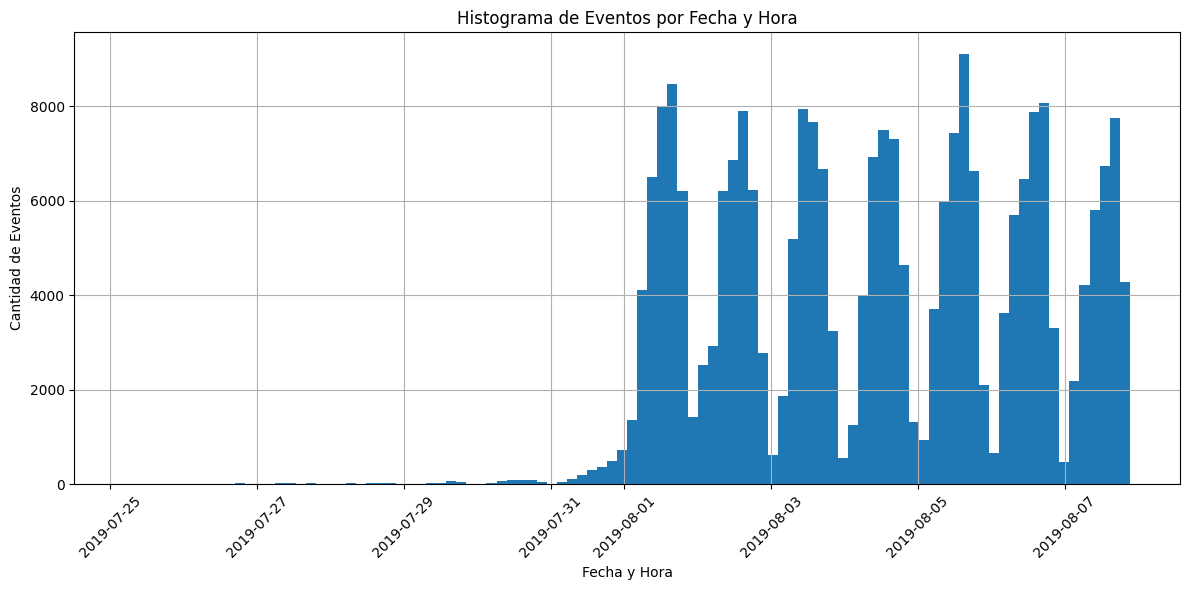

In [18]:
# Crear un histograma por fecha y hora
plt.figure(figsize=(12, 6))
registros_df['EventTimestamp'].hist(bins=100)
plt.title('Histograma de Eventos por Fecha y Hora')
plt.xlabel('Fecha y Hora')
plt.ylabel('Cantidad de Eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [19]:
# Contar eventos por fecha para evaluar completitud
eventos_por_fecha = registros_df['EventTimestamp'].dt.date.value_counts().sort_index()
print("\nEventos por fecha:")
print(eventos_por_fecha)


Eventos por fecha:
2019-07-25        9
2019-07-26       31
2019-07-27       55
2019-07-28      105
2019-07-29      184
2019-07-30      413
2019-07-31     2031
2019-08-01    36229
2019-08-02    35606
2019-08-03    33351
2019-08-04    33033
2019-08-05    36113
2019-08-06    35822
2019-08-07    31144
Name: EventTimestamp, dtype: int64


In [20]:
# Determinar el momento en que los datos comienzan a estar completos
# Consideramos que los datos son completos cuando el volumen de eventos se estabiliza
umbral_eventos = 30000  # Umbral aproximado basado en la observación de datos estables
fecha_completa = eventos_por_fecha[eventos_por_fecha > umbral_eventos].index.min()
print(f"\nFecha en la que los datos comienzan a estar completos: {fecha_completa}")

# Filtrar datos para el período completo
registros_completos_df = registros_df[registros_df['EventTimestamp'].dt.date >= fecha_completa]
fecha_maxima_completa = registros_completos_df['EventTimestamp'].max()
print(f"Período con datos completos: desde {fecha_completa} hasta {fecha_maxima_completa}")


Fecha en la que los datos comienzan a estar completos: 2019-08-01
Período con datos completos: desde 2019-08-01 hasta 2019-08-07 21:15:17


### Observación:
Los eventos son prácticamente inexistentes entre el 25 de julio del 2019 y el 31 de julio del mismo año. Por lo que se trabajará con los datos comprendidos en el periodo del 1ro de agosto del 2019 al 7 de agosto del 2019.

### 3.5 Revisar la cantidad de registros completos

In [21]:
# Calcular eventos y usuarios totales antes de filtrar
total_eventos = registros_df.shape[0]
usuarios_unicos = registros_df['SourceID'].nunique()
print(f"Total de eventos antes de filtrar: {total_eventos}")
print(f"Total de usuarios únicos antes de filtrar: {usuarios_unicos}")

Total de eventos antes de filtrar: 244126
Total de usuarios únicos antes de filtrar: 7551


In [22]:
# Eventos totales y usuarios únicos depués de filtrar
eventos_filtrados = registros_completos_df.shape[0]
usuarios_unicos_filtrados = registros_completos_df['SourceID'].nunique()
print(f"\nTotal de eventos después de filtrar: {eventos_filtrados}")
print(f"Total de usuarios únicos después de filtrar: {usuarios_unicos_filtrados}")


Total de eventos después de filtrar: 241298
Total de usuarios únicos después de filtrar: 7534


In [23]:
# Calcular eventos y usuarios perdidos
eventos_perdidos = total_eventos - eventos_filtrados
usuarios_perdidos = usuarios_unicos - usuarios_unicos_filtrados
porcentaje_eventos_perdidos = round(eventos_perdidos / total_eventos * 100, 2)
porcentaje_usuarios_perdidos = round(usuarios_perdidos / usuarios_unicos * 100,2)
print(f"\nEventos perdidos: {eventos_perdidos} ({porcentaje_eventos_perdidos}%)")
print(f"Usuarios perdidos: {usuarios_perdidos} ({porcentaje_usuarios_perdidos}%)")


Eventos perdidos: 2828 (1.16%)
Usuarios perdidos: 17 (0.23%)


In [24]:
# Verificar usuarios en cada grupo experimental en los datos filtrados
usuarios_por_grupo = registros_completos_df.groupby('Group')['SourceID'].nunique()
print("\nUsuarios únicos por grupo en los datos filtrados:")
print(usuarios_por_grupo)


Usuarios únicos por grupo en los datos filtrados:
Group
A1    2484
A2    2513
B     2537
Name: SourceID, dtype: int64


### Observaciones:
- Al comparar los eventos completos contra los eventos totales de los datos crudos, se observa una pequeña pérdida de eventos (1.16%) y de usuarios (0.23%). Lo que es aceptable para trabajar con los datos supervivientes.
- Se corroboró que los datos completos tienen una cantidad suficiente de usuarios (únicos), en los tres grupos.

## 4 Estudiar el embudo de eventos

### 4.1 Observar qué eventos hay en los registros y su frecuencia de suceso. Ordenarlos por frecuencia.

In [25]:
# Obtener los tipos de evento y su cantidad
eventos = registros_completos_df['Event'].value_counts()

In [26]:
# Imprimir los tipos de eventos y sus cantidades
print(eventos)

MainScreenAppear           117431
OffersScreenAppear          46350
CartScreenAppear            42365
PaymentScreenSuccessful     34113
Tutorial                     1039
Name: Event, dtype: int64


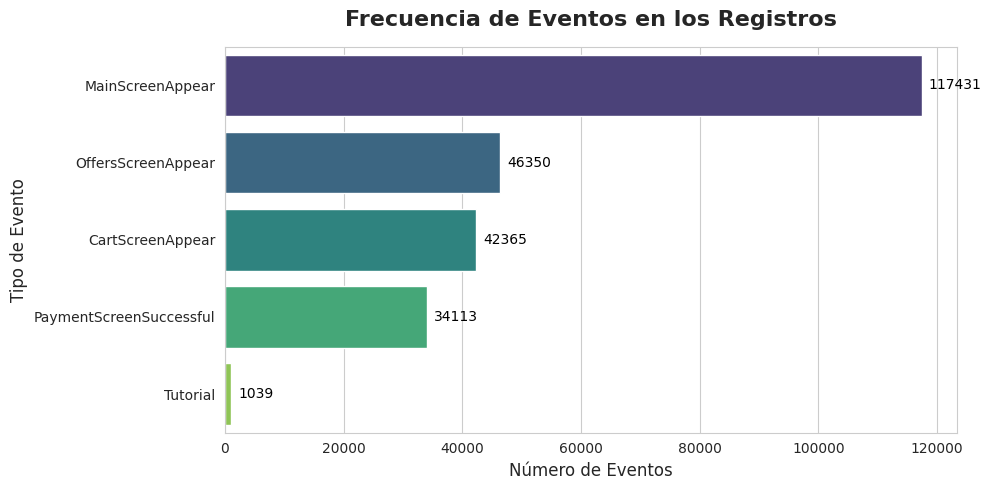

In [27]:
# Configurar estilo de seaborn para una gráfica atractiva
sns.set_style("whitegrid")

# Crear la gráfica de barras
plt.figure(figsize=(10, 5))  # Tamaño de la figura
sns.barplot(x=eventos.values, y=eventos.index, palette='viridis')

# Personalizar la gráfica
plt.title('Frecuencia de Eventos en los Registros', fontsize=16, pad=15, weight='bold')
plt.xlabel('Número de Eventos', fontsize=12)
plt.ylabel('Tipo de Evento', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Añadir valores en las barras para mayor claridad
for i, value in enumerate(eventos.values):
    plt.text(value + max(eventos.values) * 0.01, i, str(value), 
             va='center', ha='left', fontsize=10, color='black')

# Ajustar diseño para evitar recortes
plt.tight_layout()

# Mostrar la gráfica
plt.show()

### Observaciones:
- El embudo muestra cómo los usuarios pasan de una etapa (evento) a otra. Luego de la etapa en la que "aparecen las ofertas en pantalla", la cantidad de suscesos disminuye lentamente; lo que indica que la mayoría de los usuarios que ven las ofertas, llega hasta la pantalla de "Pago Exitoso" (son compradores).
- El "tutorial" tiene un pequeña cantidad de eventos, parece que la gran mayoría de los usuarios no se molesta en verlo.

### 4.2 Encontrar la cantidad de usuarios que realizaron cada una de estas acciones. Ordenar los eventos por el número de usuarios. Calcular la proporción de usuarios que realizaron la acción al menos una vez.

In [28]:
# Calcular la cantidad de usuarios únicos por evento
usuarios_por_evento = registros_completos_df.groupby('Event')['SourceID'].nunique().sort_values(ascending=False)

# Calcular el total de usuarios únicos en el dataset
total_usuarios = registros_completos_df['SourceID'].nunique()

# Calcular la proporción de usuarios que realizaron cada acción al menos una vez
proporcion_usuarios = (usuarios_por_evento / total_usuarios).round(4)

In [29]:
# Combinar los datos en un DataFrame para visualización
resultados_eventos = pd.DataFrame({
    'Usuarios': usuarios_por_evento,
    'Proporción': proporcion_usuarios
}).reset_index()

# Imprimir los resultados
resultados_eventos

,Event,Usuarios,Proporción
0,MainScreenAppear,7419,0.9847
1,OffersScreenAppear,4593,0.6096
2,CartScreenAppear,3734,0.4956
3,PaymentScreenSuccessful,3539,0.4697
4,Tutorial,840,0.1115


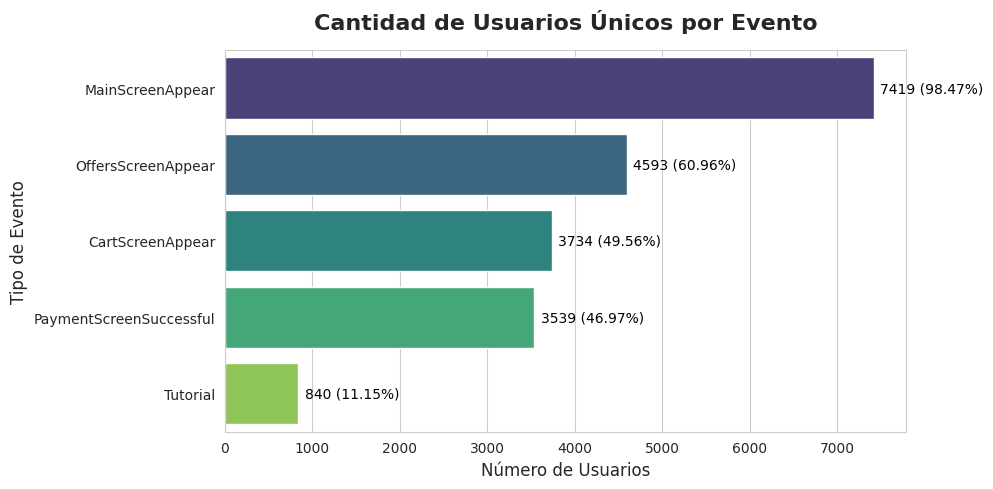

In [30]:
# Configurar estilo de seaborn para una gráfica atractiva
sns.set_style("whitegrid")

# Crear la gráfica de barras
plt.figure(figsize=(10, 5))  # Tamaño de la figura
sns.barplot(x=usuarios_por_evento.values, y=usuarios_por_evento.index, palette='viridis')

# Personalizar la gráfica
plt.title('Cantidad de Usuarios Únicos por Evento', fontsize=16, pad=15, weight='bold')
plt.xlabel('Número de Usuarios', fontsize=12)
plt.ylabel('Tipo de Evento', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Añadir valores en las barras para mayor claridad
for i, value in enumerate(usuarios_por_evento.values):
    plt.text(value + max(usuarios_por_evento.values) * 0.01, i, f"{value} ({proporcion_usuarios[i]:.2%})", 
             va='center', ha='left', fontsize=10, color='black')

# Ajustar diseño para evitar recortes
plt.tight_layout()

# Mostrar la gráfica
plt.show()

### Observaciones:
- Hasta el 61% de los usuarios pasaron de la "Pantalla Principal" a la "Pantalla de Ofertas". De ahí, el 47% del total de usuarios realizó al menos una compra (Pantalla de Pago Exitoso).
- Sólo el 11% de los usuarios vio el tutorial, lo que parece indicar que la mayoría se lo salta.

### Orden de las acciones.
Un usuario que usa la plataforma de compras, debería ver la siguiente secuencia:
1. Pantalla principal.
2. Tutorial.
3. Pantalla de ofertas.
4. Pantalla de datos de la tarjeta (crédito o débito).
5. Pantalla de pago exitoso.

### 4.3 Utilizar el embudo de eventos para encontrar la proporción de usuarios que pasan de una etapa a la siguiente. Por ejemplo, para la secuencia de eventos A → B → C, calcular la proporción de usuarios en la etapa B a la cantidad de usuarios en la etapa A y la proporción de usuarios en la etapa C a la cantidad en la etapa B.

In [31]:
# Definir el orden del embudo, excluyendo 'Tutorial' ya que no forma parte de la secuencia principal
embudo_etapas = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']

# Calcular el número de usuarios únicos en cada etapa del embudo
usuarios_embudo = registros_completos_df[registros_completos_df['Event'].isin(embudo_etapas)].groupby('Event')['SourceID'].nunique().reindex(embudo_etapas)

In [32]:
# Calcular las proporciones de paso a la siguiente etapa
proporciones = {}
for i in range(1, len(embudo_etapas)):
    etapa_anterior = embudo_etapas[i-1]
    etapa_actual = embudo_etapas[i]
    prop = round(usuarios_embudo[etapa_actual] / usuarios_embudo[etapa_anterior], 4)
    proporciones[f'{etapa_anterior} → {etapa_actual}'] = prop

# Imprimir las proporciones
print("Proporciones de usuarios que pasan de una etapa a la siguiente:")
for key, value in proporciones.items():
    print(f"{key}: {value} ({value * 100:.2f}%)")

Proporciones de usuarios que pasan de una etapa a la siguiente:
MainScreenAppear → OffersScreenAppear: 0.6191 (61.91%)
OffersScreenAppear → CartScreenAppear: 0.813 (81.30%)
CartScreenAppear → PaymentScreenSuccessful: 0.9478 (94.78%)


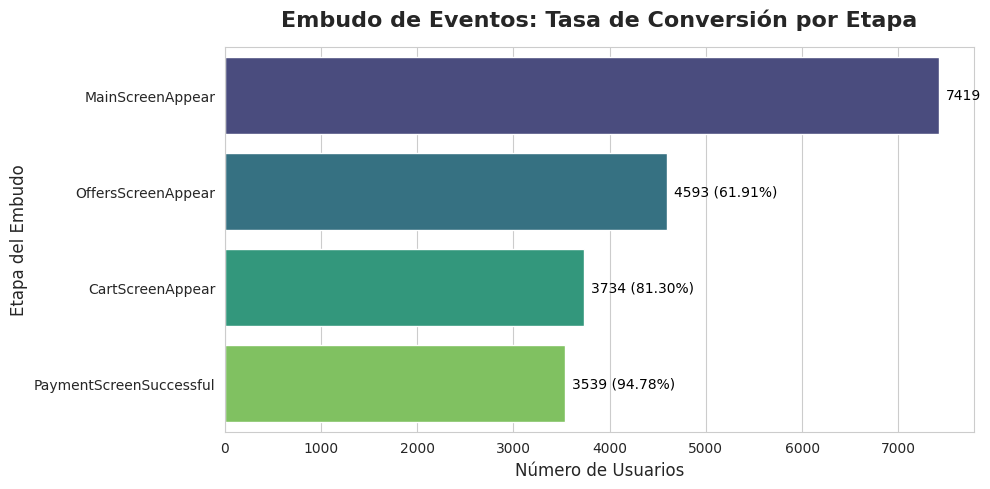

In [33]:
# Configurar estilo de seaborn para una gráfica atractiva
sns.set_style("whitegrid")

# Crear una gráfica de embudo (funnel plot) usando barras horizontales descendentes
plt.figure(figsize=(10, 5))
sns.barplot(x=usuarios_embudo.values, y=usuarios_embudo.index, palette='viridis')

# Personalizar la gráfica
plt.title('Embudo de Eventos: Tasa de Conversión por Etapa', fontsize=16, pad=15, weight='bold')
plt.xlabel('Número de Usuarios', fontsize=12)
plt.ylabel('Etapa del Embudo', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Añadir valores y proporciones al lado de las barras
for i, (etapa, value) in enumerate(usuarios_embudo.items()):
    if i == 0:
        # Para la primera etapa, solo mostrar el número de usuarios
        plt.text(value + max(usuarios_embudo.values) * 0.01, i, f"{value}", 
                 va='center', ha='left', fontsize=10, color='black')
    else:
        # Para las demás etapas, mostrar el número de usuarios y la proporción respecto a la etapa anterior
        prop = round(value / usuarios_embudo.iloc[i-1], 4)
        plt.text(value + max(usuarios_embudo.values) * 0.01, i, f"{value} ({prop * 100:.2f}%)", 
                 va='center', ha='left', fontsize=10, color='black')

# Ajustar diseño para evitar recortes
plt.tight_layout()

# Mostrar la gráfica
plt.show()

### Observaciones:
- El paso de la "Pantalla Principal" a la "Pantalla de Ofertas", es la etapa en la que se pierden más usuarios; con 62% de los usuarios avanzando de la primera pantalla a la segunda. Es decir, casi 4 de cada 10 usuarios que ven la pantalla principal, abandonan la plataforma.
- La etapa "Pantalla de Ofertas" a "Pantalla de Tarjeta", tiene una alta tasa de conversión con un 81%.
- La etapa final, "Pantalla de Tarjeta" a "Pantalla de Pago Exitoso", presenta la tasa de conversión más alta con un 95%. Valdría la pena investigar por qué hay un 5% que no completa el pago.

### 4.4 ¿Qué porcentaje de usuarios hace todo el viaje desde su primer evento hasta el pago?

In [34]:
# Obtener los SourceID que aparecen en cada evento
sourceids_por_evento = {
    etapa: set(registros_completos_df[registros_completos_df['Event'] == etapa]['SourceID'])
    for etapa in embudo_etapas
}

# Encontrar los SourceID que aparecen en los 4 eventos (intersección)
sourceids_completos = set.intersection(*sourceids_por_evento.values())

# Calcular el número de usuarios que completan todo el viaje
usuarios_completos = len(sourceids_completos)

# Calcular el porcentaje de usuarios que completan todo el viaje (respecto a MainScreenAppear)
usuarios_inicio = usuarios_embudo['MainScreenAppear']
porcentaje_completo = round((usuarios_completos / usuarios_inicio) * 100, 2)

# Imprimir resultados
print(f"Número de usuarios que completan los 4 eventos: {usuarios_completos}")
print(f"Porcentaje de usuarios que completan todo el viaje desde MainScreenAppear hasta PaymentScreenSuccessful: {porcentaje_completo}%")


Número de usuarios que completan los 4 eventos: 3429
Porcentaje de usuarios que completan todo el viaje desde MainScreenAppear hasta PaymentScreenSuccessful: 46.22%


### Respuesta: El 46.22% de los usuarios realiza todo el viaje.

## 5 Estudiar los resultados del experimento

### 5.1 ¿Cuántos usuarios hay en cada grupo?

In [35]:
# Mostrar los usuarios únicos por grupo
print("Número de usuarios únicos en cada grupo:")
for grupo, num_usuarios in usuarios_por_grupo.items():
    print(f"Grupo {grupo}: {num_usuarios} usuarios")

Número de usuarios únicos en cada grupo:
Grupo A1: 2484 usuarios
Grupo A2: 2513 usuarios
Grupo B: 2537 usuarios


### 5.2 Tenemos dos grupos de control en el test A/A, donde comprobamos nuestros mecanismos y cálculos. Observar si hay una diferencia estadísticamente significativa entre las muestras A1 (246) y A2 (247).

In [36]:
# Filtrar datos para los grupos de control (246 y 247)
control_groups = registros_completos_df[registros_completos_df['Group'].isin(['A1', 'A2'])]

# Obtener usuarios únicos por grupo
total_users = control_groups.groupby('Group')['SourceID'].nunique()
total_users_A1 = total_users['A1']
total_users_A2 = total_users['A2']

# Obtener usuarios únicos por evento y grupo
events = control_groups['Event'].unique()
event_users = control_groups.groupby(['Group', 'Event'])['SourceID'].nunique().unstack().fillna(0)

In [37]:
# Función para realizar la prueba de chi-cuadrado
def chi_squared_test(count1, count2, nobs1, nobs2, alpha=0.05):
    table = [[count1, nobs1 - count1], [count2, nobs2 - count2]]
    chi2, p_value, _, _ = stats.chi2_contingency(table, correction=False)
    return p_value, p_value < alpha

In [38]:
# Realizar la prueba para cada evento
alpha = 0.05
num_tests = len(events)
bonferroni_alpha = alpha / num_tests

In [39]:
print("Resultados del test A/A (Grupos 246 vs 247):\n")
for event in events:
    users_A1 = event_users.loc['A1', event] if event in event_users.loc['A1'] else 0
    users_A2 = event_users.loc['A2', event] if event in event_users.loc['A2'] else 0
    prop_A1 = users_A1 / total_users_A1
    prop_A2 = users_A2 / total_users_A2
    
    p_value, is_significant = chi_squared_test(users_A1, users_A2, total_users_A1, total_users_A2, bonferroni_alpha)
    
    print(f"Evento: {event}")
    print(f"  Usuarios en Grupo 246: {int(users_A1)} ({prop_A1:.2%})")
    print(f"  Usuarios en Grupo 247: {int(users_A2)} ({prop_A2:.2%})")
    print(f"  P-valor: {p_value:.4f}")
    print(f"  ¿Diferencia significativa (Bonferroni α={bonferroni_alpha:.5f})?: {'Sí' if is_significant else 'No'}\n")

Resultados del test A/A (Grupos 246 vs 247):

Evento: Tutorial
  Usuarios en Grupo 246: 278 (11.19%)
  Usuarios en Grupo 247: 283 (11.26%)
  P-valor: 0.9377
  ¿Diferencia significativa (Bonferroni α=0.01000)?: No

Evento: MainScreenAppear
  Usuarios en Grupo 246: 2450 (98.63%)
  Usuarios en Grupo 247: 2476 (98.53%)
  P-valor: 0.7571
  ¿Diferencia significativa (Bonferroni α=0.01000)?: No

Evento: OffersScreenAppear
  Usuarios en Grupo 246: 1542 (62.08%)
  Usuarios en Grupo 247: 1520 (60.49%)
  P-valor: 0.2481
  ¿Diferencia significativa (Bonferroni α=0.01000)?: No

Evento: PaymentScreenSuccessful
  Usuarios en Grupo 246: 1200 (48.31%)
  Usuarios en Grupo 247: 1158 (46.08%)
  P-valor: 0.1146
  ¿Diferencia significativa (Bonferroni α=0.01000)?: No

Evento: CartScreenAppear
  Usuarios en Grupo 246: 1266 (50.97%)
  Usuarios en Grupo 247: 1238 (49.26%)
  P-valor: 0.2288
  ¿Diferencia significativa (Bonferroni α=0.01000)?: No



### Observación:
No hay una diferencia significativa entre los grupos A1 (246) Y A2 (247), en ninguno de los eventos, por lo que ambos grupos cumplen como grupos de control.

### 5.3 Seleccionar el evento más popular. En cada uno de los grupos de control, encontrar la cantidad de usuarios que realizaron esta acción. Encontrar su proporción. Comprobar si la diferencia entre los grupos es estadísticamente significativa. Repetir el procedimiento para todos los demás eventos. ¿Se confirmar que los grupos se dividieron correctamente?

In [40]:
# Paso 1: Identificar el evento más popular (mayor número de usuarios únicos en total)
total_users_per_event = registros_completos_df.groupby('Event')['SourceID'].nunique()
most_popular_event = total_users_per_event.idxmax()
most_popular_users = total_users_per_event.max()

In [41]:
# Paso 2: Realizar pruebas para todos los eventos, empezando por el más popular, con chi_squared_test
alpha = 0.05
num_tests = len(events)  # Reusar events de código previo
bonferroni_alpha = alpha / num_tests

print(f"Evento más popular: {most_popular_event} con {most_popular_users} usuarios únicos (incluyendo todos los grupos)\n")
print("Resultados del test A/A (Grupos A1 vs A2):\n")

# Ordenar eventos para mostrar el más popular primero
sorted_events = [most_popular_event] + [e for e in events if e != most_popular_event]

for event in sorted_events:
    users_a1 = event_users.loc['A1', event] if event in event_users.loc['A1'] else 0
    users_a2 = event_users.loc['A2', event] if event in event_users.loc['A2'] else 0
    prop_a1 = users_a1 / total_users['A1']
    prop_a2 = users_a2 / total_users['A2']
    
    p_value, is_significant = chi_squared_test(users_a1, users_a2, total_users['A1'], total_users['A2'], bonferroni_alpha)
    
    print(f"Evento: {event}")
    print(f"  Usuarios en Grupo A1: {int(users_a1)} ({prop_a1:.2%})")
    print(f"  Usuarios en Grupo A2: {int(users_a2)} ({prop_a2:.2%})")
    print(f"  P-valor: {p_value:.4f}")
    print(f"  ¿Diferencia significativa (Bonferroni α={bonferroni_alpha:.5f})?: {'Sí' if is_significant else 'No'}\n")

Evento más popular: MainScreenAppear con 7419 usuarios únicos (incluyendo todos los grupos)

Resultados del test A/A (Grupos A1 vs A2):

Evento: MainScreenAppear
  Usuarios en Grupo A1: 2450 (98.63%)
  Usuarios en Grupo A2: 2476 (98.53%)
  P-valor: 0.7571
  ¿Diferencia significativa (Bonferroni α=0.01000)?: No

Evento: Tutorial
  Usuarios en Grupo A1: 278 (11.19%)
  Usuarios en Grupo A2: 283 (11.26%)
  P-valor: 0.9377
  ¿Diferencia significativa (Bonferroni α=0.01000)?: No

Evento: OffersScreenAppear
  Usuarios en Grupo A1: 1542 (62.08%)
  Usuarios en Grupo A2: 1520 (60.49%)
  P-valor: 0.2481
  ¿Diferencia significativa (Bonferroni α=0.01000)?: No

Evento: PaymentScreenSuccessful
  Usuarios en Grupo A1: 1200 (48.31%)
  Usuarios en Grupo A2: 1158 (46.08%)
  P-valor: 0.1146
  ¿Diferencia significativa (Bonferroni α=0.01000)?: No

Evento: CartScreenAppear
  Usuarios en Grupo A1: 1266 (50.97%)
  Usuarios en Grupo A2: 1238 (49.26%)
  P-valor: 0.2288
  ¿Diferencia significativa (Bonferroni α

In [42]:
print(f"Se realizaron {num_tests} pruebas, con un nivel de significancia ajustado de {bonferroni_alpha:.5f} (Bonferroni).")

Se realizaron 5 pruebas, con un nivel de significancia ajustado de 0.01000 (Bonferroni).


### Observación:
No hay diferencias significativas (p-valor > Bonferroni α), en ninguno de los eventos, plor lo que; los grupos de control A1 y A2 están correctamente divididos.

### 5.4 Realizar las mismas operaciones que en el paso anterior, con base en el grupo B (248) y compararlo contra los grupos de control.

In [43]:
# Datos para el grupo B
group_b = registros_completos_df[registros_completos_df['Group'] == 'B']
total_users_b = group_b['SourceID'].nunique()

In [44]:
# Datos para el control combinado (A1 + A2)
combined_a = registros_completos_df[registros_completos_df['Group'].isin(['A1', 'A2'])]
total_users_combined_a = combined_a['SourceID'].nunique()

# Usuarios por evento para B y control combinado
event_users_b = group_b.groupby('Event')['SourceID'].nunique().fillna(0)
event_users_combined_a = combined_a.groupby('Event')['SourceID'].nunique().fillna(0)

In [46]:
print(f"Evento más popular: {most_popular_event}\n")

Evento más popular: MainScreenAppear



In [53]:
# Nivel de significancia con corrección Bonferroni (por número de eventos)
alpha = 0.05
num_tests = len(events)  # Reusar events del código anterior
bonferroni_alpha = alpha / num_tests

# Ordenar eventos para mostrar el más popular primero
sorted_events = [most_popular_event] + [e for e in events if e != most_popular_event]

print("Resultados del test A/B (Grupo B vs A1, A2 y Combinado A, α=0.0.5):\n")

# Comparaciones: B vs A1, B vs A2, B vs Combinado A
for event in sorted_events:
    # Datos para B
    users_b = event_users_b.get(event, 0)
    prop_b = users_b / total_users_b
    
    # B vs A1
    users_a1 = event_users.loc['A1', event] if event in event_users.loc['A1'] else 0
    prop_a1 = users_a1 / total_users['A1']
    p_value_a1, sig_a1 = chi_squared_test(users_b, users_a1, total_users_b, total_users['A1'], bonferroni_alpha)
    
    # B vs A2
    users_a2 = event_users.loc['A2', event] if event in event_users.loc['A2'] else 0
    prop_a2 = users_a2 / total_users['A2']
    p_value_a2, sig_a2 = chi_squared_test(users_b, users_a2, total_users_b, total_users['A2'], bonferroni_alpha)
    
    # B vs Combinado A
    users_combined_a = event_users_combined_a.get(event, 0)
    prop_combined_a = users_combined_a / total_users_combined_a
    p_value_combined, sig_combined = chi_squared_test(users_b, users_combined_a, total_users_b, total_users_combined_a, bonferroni_alpha)
    
    print(f"Evento: {event}")
    print(f"  Usuarios en Grupo B: {int(users_b)} ({prop_b:.2%})")
    print(f"  --- vs A1: Usuarios {int(users_a1)} ({prop_a1:.2%}), P-valor: {p_value_a1:.4f}, Significativa: {'Sí' if sig_a1 else 'No'}")
    print(f"  --- vs A2: Usuarios {int(users_a2)} ({prop_a2:.2%}), P-valor: {p_value_a2:.4f}, Significativa: {'Sí' if sig_a2 else 'No'}")
    print(f"  --- vs Combinado A: Usuarios {int(users_combined_a)} ({prop_combined_a:.2%}), P-valor: {p_value_combined:.4f}, Significativa: {'Sí' if sig_combined else 'No'}\n")

Resultados del test A/B (Grupo B vs A1, A2 y Combinado A, α=0.0.5):

Evento: MainScreenAppear
  Usuarios en Grupo B: 2493 (98.27%)
  --- vs A1: Usuarios 2450 (98.63%), P-valor: 0.2950, Significativa: No
  --- vs A2: Usuarios 2476 (98.53%), P-valor: 0.4587, Significativa: No
  --- vs Combinado A: Usuarios 4926 (98.58%), P-valor: 0.2942, Significativa: No

Evento: Tutorial
  Usuarios en Grupo B: 279 (11.00%)
  --- vs A1: Usuarios 278 (11.19%), P-valor: 0.8264, Significativa: No
  --- vs A2: Usuarios 283 (11.26%), P-valor: 0.7653, Significativa: No
  --- vs Combinado A: Usuarios 561 (11.23%), P-valor: 0.7649, Significativa: No

Evento: OffersScreenAppear
  Usuarios en Grupo B: 1531 (60.35%)
  --- vs A1: Usuarios 1542 (62.08%), P-valor: 0.2084, Significativa: No
  --- vs A2: Usuarios 1520 (60.49%), P-valor: 0.9198, Significativa: No
  --- vs Combinado A: Usuarios 3062 (61.28%), P-valor: 0.4343, Significativa: No

Evento: PaymentScreenSuccessful
  Usuarios en Grupo B: 1181 (46.55%)
  --- vs

In [48]:
print(f"Nivel de significancia ajustado: {bonferroni_alpha:.5f} (Bonferroni para {num_tests} eventos).")

Nivel de significancia ajustado: 0.01000 (Bonferroni para 5 eventos).


### Observación.
Con un nivel de significancia alfa de 0.05, NO se encontró una diferencia SIGNIFICATIVA entre el grupo B (248), con fuentes alteradas, y los dos grupos de control (A1 y A2), tanto por separado como de forma combinada. Por lo tanto, estas pruebas muestran que las fuentes nuevas (Grupo B) no afectan el comportamiento de los usuarios de manera significativa.

### 5.5 Repetir las pruebas usando un nivel de significancia de 0.1

In [52]:
# Nivel de significancia con corrección Bonferroni (por número de eventos)
alpha = 0.1
num_tests = len(events)  # Reusar events del código anterior
bonferroni_alpha = alpha / num_tests

# Ordenar eventos para mostrar el más popular primero
sorted_events = [most_popular_event] + [e for e in events if e != most_popular_event]

print("Resultados del test A/B (Grupo B vs A1, A2 y Combinado A, α=0.1):\n")

# Comparaciones: B vs A1, B vs A2, B vs Combinado A
for event in sorted_events:
    # Datos para B
    users_b = event_users_b.get(event, 0)
    prop_b = users_b / total_users_b
    
    # B vs A1
    users_a1 = event_users.loc['A1', event] if event in event_users.loc['A1'] else 0
    prop_a1 = users_a1 / total_users['A1']
    p_value_a1, sig_a1 = chi_squared_test(users_b, users_a1, total_users_b, total_users['A1'], bonferroni_alpha)
    
    # B vs A2
    users_a2 = event_users.loc['A2', event] if event in event_users.loc['A2'] else 0
    prop_a2 = users_a2 / total_users['A2']
    p_value_a2, sig_a2 = chi_squared_test(users_b, users_a2, total_users_b, total_users['A2'], bonferroni_alpha)
    
    # B vs Combinado A
    users_combined_a = event_users_combined_a.get(event, 0)
    prop_combined_a = users_combined_a / total_users_combined_a
    p_value_combined, sig_combined = chi_squared_test(users_b, users_combined_a, total_users_b, total_users_combined_a, bonferroni_alpha)
    
    print(f"Evento: {event}")
    print(f"  Usuarios en Grupo B: {int(users_b)} ({prop_b:.2%})")
    print(f"  --- vs A1: Usuarios {int(users_a1)} ({prop_a1:.2%}), P-valor: {p_value_a1:.4f}, Significativa: {'Sí' if sig_a1 else 'No'}")
    print(f"  --- vs A2: Usuarios {int(users_a2)} ({prop_a2:.2%}), P-valor: {p_value_a2:.4f}, Significativa: {'Sí' if sig_a2 else 'No'}")
    print(f"  --- vs Combinado A: Usuarios {int(users_combined_a)} ({prop_combined_a:.2%}), P-valor: {p_value_combined:.4f}, Significativa: {'Sí' if sig_combined else 'No'}\n")

    print(f"Nivel de significancia ajustado: {bonferroni_alpha:.5f} (Bonferroni para {num_tests} eventos).")

Resultados del test A/B (Grupo B vs A1, A2 y Combinado A, α=0.1):

Evento: MainScreenAppear
  Usuarios en Grupo B: 2493 (98.27%)
  --- vs A1: Usuarios 2450 (98.63%), P-valor: 0.2950, Significativa: No
  --- vs A2: Usuarios 2476 (98.53%), P-valor: 0.4587, Significativa: No
  --- vs Combinado A: Usuarios 4926 (98.58%), P-valor: 0.2942, Significativa: No

Nivel de significancia ajustado: 0.02000 (Bonferroni para 5 eventos).
Evento: Tutorial
  Usuarios en Grupo B: 279 (11.00%)
  --- vs A1: Usuarios 278 (11.19%), P-valor: 0.8264, Significativa: No
  --- vs A2: Usuarios 283 (11.26%), P-valor: 0.7653, Significativa: No
  --- vs Combinado A: Usuarios 561 (11.23%), P-valor: 0.7649, Significativa: No

Nivel de significancia ajustado: 0.02000 (Bonferroni para 5 eventos).
Evento: OffersScreenAppear
  Usuarios en Grupo B: 1531 (60.35%)
  --- vs A1: Usuarios 1542 (62.08%), P-valor: 0.2084, Significativa: No
  --- vs A2: Usuarios 1520 (60.49%), P-valor: 0.9198, Significativa: No
  --- vs Combinado A:

### Observación:
Las diferencias entre el grupo B y los grupos de control, A1 y A2, siguen siendo NO significativas, aún con un valor alfa de 0.1

# Conclusión del Experimento A/A/B

**Resultados del Análisis**

Las pruebas demostraron que los resultados del grupo B (248), con nuevas fuentes, NO tienen una diferencia significativa con los grupos de control, A1 (246) Y A2 (247). Es decir, que las nuevas fuentes NO tuvieron un impacto significativo en el comportamiento de los usuarios (el porcenaje de usuarios por evento fue similar en los 3 grupos). Por lo tanto, se concluye que el experimento ha sido un FRACASO y debería desecharse el uso de fuentes alternativas para la aplicación (de la empresa alimenticia emergente).

**Recomendación**

Dado que no se observaron diferencias significativas, se recomienda mantener las fuentes actuales de la aplicación.